# Appendicitis Prediction — Q-Learning vs RAMAAS Baseline

**RL Framing สำหรับ Medical Data:**
- **State**: binary encoding ของอาการผู้ป่วย 1 ราย (แต่ละ row = 1 episode / contextual bandit)
- **Action**: 0 = ไม่ผ่าตัด, 1 = ผ่าตัด
- **Reward**: คะแนนที่สะท้อน medical cost ของการตัดสินใจผิด
- **เป้าหมาย**: Balance ระหว่าง FN (คนไข้หลุด) และ FP (ผ่าเก้อ)

**Reward ที่ใช้** (ได้จาก Reward Sweep 36 combinations):
| Case | Reward | เหตุผล |
|------|--------|---------|
| TP | +15 | รักษาคนไข้ถูกต้อง |
| TN | +10 | ไม่เสียทรัพยากรโดยไม่จำเป็น |
| FP | -100 | ผ่าตัดโดยไม่จำเป็น มี risk และ cost |
| FN | -100 | พลาดคนป่วย อันตราย — Ratio 1:1 เพื่อ balance |

## Cell 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

np.random.seed(42)

# ---- Thai Font Setup ----
thai_candidates = ['Thonburi', 'TH Sarabun New', 'Noto Sans Thai', 'Tahoma', 'Arial Unicode MS']
thai_font = None
for font in thai_candidates:
    if fm.findfont(fm.FontProperties(family=font), fallback_to_default=False):
        thai_font = font
        break
if thai_font:
    plt.rcParams['font.family'] = thai_font
    print(f'Thai font: {thai_font}')
else:
    print('Thai font not found')

Thai font: Thonburi


## Cell 2 — Constants, Feature Engineering & Helper Functions

**State Space**: 9 bits → 2^9 = 512 possible states
- 7 base features + 2 interaction features (High_Risk, Classic_Sign)

In [5]:
BASE_FEATURES = ['Progression', 'Migration', 'Aggravation', 'TEMP', 'Rebound', 'WBC', 'Neut']
TARGET        = 'appendicitis'
# ตัด interaction features ออกแล้ว: ทดสอบพบว่า FN เท่ากัน ไม่มีประโยชน์เพิ่ม
N_STATES      = 2 ** len(BASE_FEATURES)  # 128
N_ACTIONS     = 2
REWARD        = {'TP': 15, 'TN': 10, 'FP': -100, 'FN': -100}
ALPHA         = 0.05
GAMMA         = 0.9
EPSILON       = 0.1
EPOCHS        = 2000
K_FOLDS       = 5


def to_bin(val):
    """แปลง categorical (yes/no, >37.8 etc.) → 0/1"""
    return 1 if str(val).lower().strip() in {'yes', '1', '1.0', '>10000', '>75', '>37.8', 'app'} else 0


def build_states(df, base_features):
    """สร้าง state index จาก 7 base features (binary encoding)"""
    data = pd.DataFrame(
        {col: df[col].map(to_bin).values for col in base_features}
    )
    states = np.array([int(''.join(map(str, row)), 2) for row in data[base_features].values])
    assert states.max() < N_STATES, f"State index เกิน {N_STATES}: {states.max()}"
    return states


def get_reward(a, truth):
    if   a == 1 and truth == 1: return REWARD['TP']
    elif a == 0 and truth == 0: return REWARD['TN']
    elif a == 1 and truth == 0: return REWARD['FP']
    else:                       return REWARD['FN']


def epsilon_greedy(q_row, eps):
    return np.random.choice(N_ACTIONS) if np.random.rand() < eps else int(np.argmax(q_row))


def train_qlearning(states, labels):
    Q, history = np.zeros((N_STATES, N_ACTIONS)), []
    for epoch in range(EPOCHS):
        epoch_rew = 0.0
        for i in range(len(states)):
            s, truth  = states[i], int(labels[i])
            a         = epsilon_greedy(Q[s], EPSILON)
            rew       = get_reward(a, truth)
            epoch_rew += rew
            Q[s, a]  += ALPHA * (rew + GAMMA * np.max(Q[s]) - Q[s, a])
        history.append(epoch_rew / len(states))
    return Q, history


def calc_metrics(y_true, preds, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    total = len(y_true)
    acc   = (tp + tn) / total
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1    = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0.0
    auc   = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float('nan')
    return dict(TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Accuracy=acc, Sensitivity=sens, Specificity=spec, F1=f1, AUC=auc)


def evaluate_ql(Q, states, y_true):
    preds = np.argmax(Q[states], axis=1)
    return calc_metrics(y_true, preds, Q[states, 1])


def evaluate_ramaas(df, y_true, threshold=0.5):
    """ประเมิน RAMAAS — สูตรดั้งเดิมจากหมอ"""
    BASE_WEIGHTS = {'Migration': 0.80, 'Progression': 1.04,
                    'Aggravation': 0.78, 'TEMP': 1.64,
                    'Rebound': 1.53, 'WBC': 0.91, 'Neut': 0.69}
    INTERCEPT = -3.37
    logit = INTERCEPT
    for feat, w in BASE_WEIGHTS.items():
        logit = logit + w * df[feat].values  # ข้อมูลเป็น 0/1 อยู่แล้ว
    probs = 1 / (1 + np.exp(-logit))
    preds = (probs >= threshold).astype(int)
    return calc_metrics(y_true, preds, probs)


print("✅ Setup เสร็จ")

✅ Setup เสร็จ


## Cell 3 — Load Data

In [6]:
df_train = pd.read_csv('TRAIN_DATASET.csv')
df_test  = pd.read_csv('TEST_DATASET.csv')

# result_compute_clean.csv เป็น binary 0/1 อยู่แล้ว ไม่ต้อง rename หรือแปลง
train_states = build_states(df_train, BASE_FEATURES)
y_train      = df_train[TARGET].map(to_bin).values
test_states  = build_states(df_test, BASE_FEATURES)
# appendicitis column เป็น 0/1 อยู่แล้ว
y_test       = df_test[TARGET].values

print(f"Train : {len(y_train)} samples (pos={y_train.sum()}, neg={(y_train==0).sum()})")
print(f"Test  : {len(y_test)}  samples (pos={y_test.sum()},  neg={(y_test==0).sum()})")
print(f"State space: {N_STATES} states")

Train : 500 samples (pos=348, neg=152)
Test  : 376  samples (pos=266,  neg=110)
State space: 128 states


## Cell 4 — 5-Fold Cross Validation

In [7]:
df_all     = pd.concat([df_train, df_test], ignore_index=True)
all_states = build_states(df_all, BASE_FEATURES)
y_all      = df_all[TARGET].map(to_bin).values

skf        = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
cv_results = []

print(f"🔄 เริ่ม {K_FOLDS}-Fold CV (Q-Learning)...\n")
for fold, (tr_idx, val_idx) in enumerate(skf.split(all_states, y_all), 1):
    Q_fold, _ = train_qlearning(all_states[tr_idx], y_all[tr_idx])
    m         = evaluate_ql(Q_fold, all_states[val_idx], y_all[val_idx])
    cv_results.append(m)
    print(f"Fold {fold}: Sens={m['Sensitivity']:.2%}  Spec={m['Specificity']:.2%}  F1={m['F1']:.4f}  FN={m['FN']}  FP={m['FP']}")

print("\n✅ CV เสร็จ")

🔄 เริ่ม 5-Fold CV (Q-Learning)...

Fold 1: Sens=96.75%  Spec=47.17%  F1=0.8815  FN=4  FP=28
Fold 2: Sens=91.06%  Spec=48.08%  F1=0.8550  FN=11  FP=27
Fold 3: Sens=96.75%  Spec=53.85%  F1=0.8947  FN=4  FP=24
Fold 4: Sens=89.43%  Spec=40.38%  F1=0.8333  FN=13  FP=31
Fold 5: Sens=86.89%  Spec=41.51%  F1=0.8185  FN=16  FP=31

✅ CV เสร็จ


## Cell 5 — สรุปผล CV + เปรียบเทียบกับ RAMAAS

In [ ]:
# CV Summary
metric_keys = ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC', 'FN', 'FP']
cv_row = {'Model': 'Q-Learning (CV)'}
for k in metric_keys:
    vals = [f[k] for f in cv_results]
    m, s = np.mean(vals), np.std(vals)
    cv_row[k] = f"{m:.1f}±{s:.1f}" if k in ['FN','FP'] else (
                f"{m:.4f}±{s:.4f}" if k in ['F1','AUC'] else f"{m:.2%}±{s:.2%}")

print("\n" + "="*105)
print(f" {K_FOLDS}-Fold CV — Q-Learning (Mean ± Std)")
print("="*105)
print(pd.DataFrame([cv_row]).to_string(index=False))
print("="*105)

# Train final & compare
print("\n🚀 Train Final Model...")
Q_final, loss_history = train_qlearning(train_states, y_train)
ql_result     = evaluate_ql(Q_final, test_states, y_test)
ramaas_result = evaluate_ramaas(df_test, y_test)

rows = []
for name, m in [('RAMAAS (Baseline)', ramaas_result), ('Q-Learning (RL)', ql_result)]:
    rows.append({'Model': name,
                 'Accuracy': f"{m['Accuracy']:.2%}", 'Sensitivity': f"{m['Sensitivity']:.2%}",
                 'Specificity': f"{m['Specificity']:.2%}", 'F1': f"{m['F1']:.4f}",
                 'AUC': f"{m['AUC']:.4f}",
                 'TP': m['TP'], 'TN': m['TN'], 'FP': m['FP'], 'FN': m['FN']})

print("\n" + "="*95)
print(" RAMAAS vs Q-Learning — Test Set ")
print("="*95)
print(pd.DataFrame(rows).to_string(index=False))
print("="*95)

print("\n📊 ความแตกต่าง (Q-Learning − RAMAAS):")
for met in ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC']:
    diff = ql_result[met] - ramaas_result[met]
    print(f"  {met:<12}: {'↑' if diff > 0 else '↓'} {abs(diff):.4f}")
print(f"  FN change   : {ql_result['FN'] - ramaas_result['FN']:+d} ราย")
print(f"  FP change   : {ql_result['FP'] - ramaas_result['FP']:+d} ราย")


 5-Fold CV — Q-Learning (Mean ± Std)
          Model     Accuracy  Sensitivity  Specificity            F1           AUC      FN       FP
Q-Learning (CV) 78.42%±4.08% 92.17%±3.96% 46.20%±4.87% 0.8566±0.0285 0.6668±0.0149 9.6±4.8 28.2±2.6

🚀 Train Final Model...

 RAMAAS vs Q-Learning — Test Set (bootstrap3)
            Model Accuracy Sensitivity Specificity     F1    AUC  TP  TN  FP  FN
RAMAAS (Baseline)   70.21%      81.20%      43.64% 0.7941 0.6947 216  48  62  50
  Q-Learning (RL)   77.13%      87.22%      52.73% 0.8436 0.6796 232  58  52  34

📊 ความแตกต่าง (Q-Learning − RAMAAS):
  Accuracy    : ↑ 0.0691
  Sensitivity : ↑ 0.0602
  Specificity : ↑ 0.0909
  F1          : ↑ 0.0495
  AUC         : ↓ 0.0151
  FN change   : -16 ราย
  FP change   : -10 ราย


## Cell 6 — Visualization

/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_87397/3209772811.py:69: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Thonburi.
  plt.savefig('turening_final_results.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Thonburi.
  fig.canvas.print_figure(bytes_io, **kw)


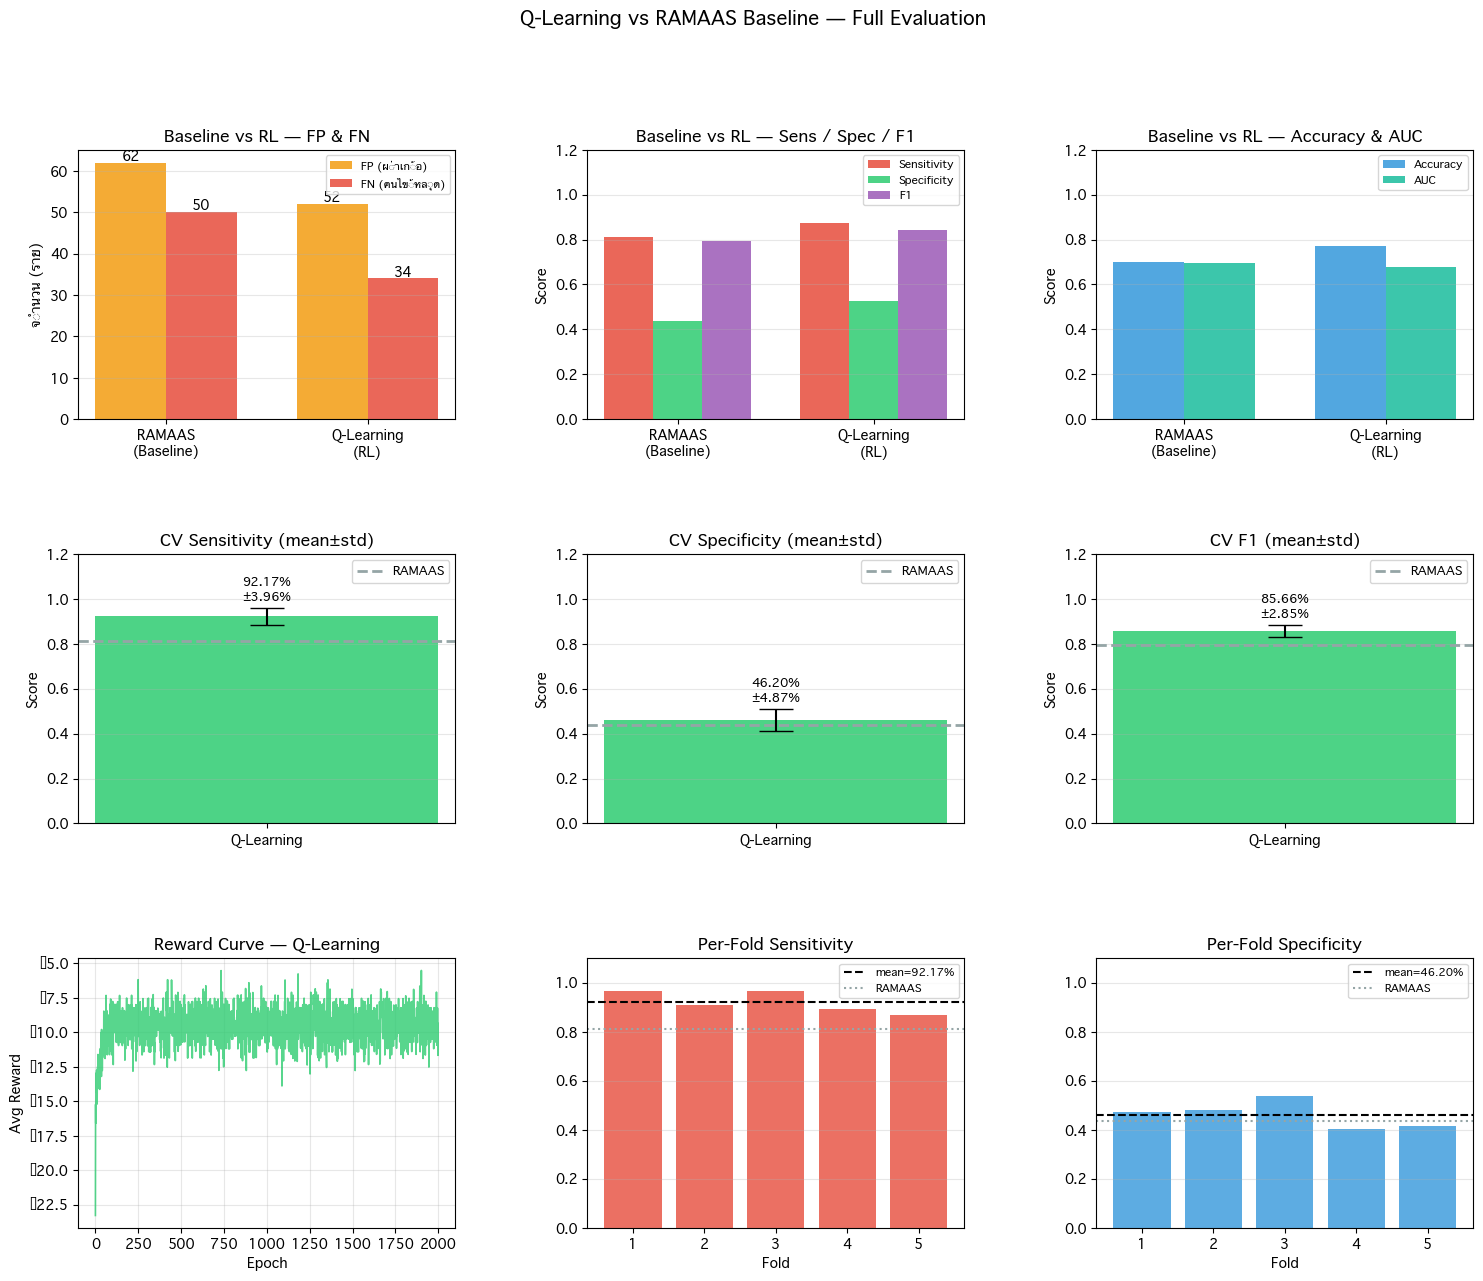

💾 บันทึกกราฟเป็น turening_final_results.png


In [9]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
cmp_data   = [ramaas_result, ql_result]
cmp_labels = ['RAMAAS\n(Baseline)', 'Q-Learning\n(RL)']
x2, w = np.arange(2), 0.35

# Row 1: Baseline vs RL
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x2-w/2, [m['FP'] for m in cmp_data], w, label='FP (ผ่าเก้อ)',   color='#f39c12', alpha=0.85)
ax1.bar(x2+w/2, [m['FN'] for m in cmp_data], w, label='FN (คนไข้หลุด)', color='#e74c3c', alpha=0.85)
ax1.set_xticks(x2); ax1.set_xticklabels(cmp_labels)
ax1.set_title('Baseline vs RL — FP & FN'); ax1.set_ylabel('จำนวน (ราย)')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)
for i, m in enumerate(cmp_data):
    ax1.text(i-w/2, m['FP']+0.5, str(m['FP']), ha='center', fontsize=10, fontweight='bold')
    ax1.text(i+w/2, m['FN']+0.5, str(m['FN']), ha='center', fontsize=10, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
for j, (met, col) in enumerate(zip(['Sensitivity','Specificity','F1'],['#e74c3c','#2ecc71','#9b59b6'])):
    ax2.bar(x2+(j-1)*0.25, [m[met] for m in cmp_data], 0.25, label=met, color=col, alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(cmp_labels)
ax2.set_ylim(0, 1.2); ax2.set_title('Baseline vs RL — Sens / Spec / F1')
ax2.set_ylabel('Score'); ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(x2-w/2, [m['Accuracy'] for m in cmp_data], w, label='Accuracy', color='#3498db', alpha=0.85)
ax3.bar(x2+w/2, [m['AUC']      for m in cmp_data], w, label='AUC',      color='#1abc9c', alpha=0.85)
ax3.set_xticks(x2); ax3.set_xticklabels(cmp_labels)
ax3.set_ylim(0, 1.2); ax3.set_title('Baseline vs RL — Accuracy & AUC')
ax3.set_ylabel('Score'); ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# Row 2: CV Mean ± Std
for col_idx, (met, title) in enumerate(zip(
        ['Sensitivity','Specificity','F1'],
        ['CV Sensitivity (mean±std)','CV Specificity (mean±std)','CV F1 (mean±std)'])):
    ax = fig.add_subplot(gs[1, col_idx])
    mv = np.mean([f[met] for f in cv_results])
    sv = np.std ([f[met] for f in cv_results])
    ax.bar([0], [mv], color='#2ecc71', alpha=0.85, yerr=[sv], capsize=12, width=0.4)
    ax.axhline(ramaas_result[met], color='#95a5a6', linestyle='--', linewidth=2, label='RAMAAS')
    ax.set_xticks([0]); ax.set_xticklabels(['Q-Learning'])
    ax.set_ylim(0, 1.2); ax.set_title(title); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.text(0, mv+sv+0.03, f"{mv:.2%}\n±{sv:.2%}", ha='center', fontsize=9, fontweight='bold')

# Row 3: Reward curve + per-fold
ax_r = fig.add_subplot(gs[2, 0])
ax_r.plot(loss_history, color='#2ecc71', linewidth=1.2, alpha=0.8)
ax_r.set_title('Reward Curve — Q-Learning')
ax_r.set_xlabel('Epoch'); ax_r.set_ylabel('Avg Reward'); ax_r.grid(alpha=0.3)

ax_f1 = fig.add_subplot(gs[2, 1])
fold_sens = [f['Sensitivity'] for f in cv_results]
ax_f1.bar(range(1, K_FOLDS+1), fold_sens, color='#e74c3c', alpha=0.8)
ax_f1.axhline(np.mean(fold_sens), color='black',   linestyle='--', linewidth=1.5, label=f"mean={np.mean(fold_sens):.2%}")
ax_f1.axhline(ramaas_result['Sensitivity'], color='#95a5a6', linestyle=':', linewidth=1.5, label='RAMAAS')
ax_f1.set_title('Per-Fold Sensitivity'); ax_f1.set_xlabel('Fold')
ax_f1.set_ylim(0, 1.1); ax_f1.legend(fontsize=8); ax_f1.grid(axis='y', alpha=0.3)

ax_f2 = fig.add_subplot(gs[2, 2])
fold_spec = [f['Specificity'] for f in cv_results]
ax_f2.bar(range(1, K_FOLDS+1), fold_spec, color='#3498db', alpha=0.8)
ax_f2.axhline(np.mean(fold_spec), color='black',   linestyle='--', linewidth=1.5, label=f"mean={np.mean(fold_spec):.2%}")
ax_f2.axhline(ramaas_result['Specificity'], color='#95a5a6', linestyle=':', linewidth=1.5, label='RAMAAS')
ax_f2.set_title('Per-Fold Specificity'); ax_f2.set_xlabel('Fold')
ax_f2.set_ylim(0, 1.1); ax_f2.legend(fontsize=8); ax_f2.grid(axis='y', alpha=0.3)

plt.suptitle('Q-Learning vs RAMAAS Baseline — Full Evaluation', fontsize=14, fontweight='bold')
plt.savefig('turening_final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 บันทึกกราฟเป็น turening_final_results.png")